# Dataset Loading

Pull data from huggingface and download

In [1]:
import tarfile
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
import io
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import random

from huggingface_hub import snapshot_download

c:\Users\yy21473\.GitHubFiles\dst-group-work\GlobalGeoTree\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:


snapshot_download(
    repo_id="yann111/GlobalGeoTree",
    repo_type="dataset",
    local_dir="./GlobalGeoTree-6M",
    allow_patterns="GlobalGeoTree-6M/*"  # Only files in this folder
)

print("Download complete!")


c:\Users\yy21473\.GitHubFiles\dst-group-work\GlobalGeoTree\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 118 files: 100%|██████████| 118/118 [01:52<00:00,  1.05it/s]

Download complete!


# Parse dataset to dataframe

## For single tar

In [3]:

tar_path = "GlobalGeoTree-6M\GlobalGeoTree-6M\GGT_3500001_3600000-000001.tar"

small_sample = []

with tarfile.open(tar_path, "r") as tar:
    for member in tar:
        if member.isfile() and member.name.endswith(".json"):
            f = tar.extractfile(member)
            if f:
                obj = json.loads(f.read().decode("utf-8"))
                small_sample.append(obj)

                if len(small_sample) >= 1000:
                    break

# Merge every two consecutive JSON objects
merged_records = []
for i in range(0, len(small_sample), 2):
    if i+1 < len(small_sample):
        merged = {**small_sample[i], **small_sample[i+1]}
        merged_records.append(merged)
    else:
        merged_records.append(small_sample[i])  # If odd, keep last as is

df = pd.DataFrame(merged_records)


<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\yy21473\AppData\Local\Temp\ipykernel_36096\2181409932.py:1: SyntaxWarning: invalid escape sequence '\G'
  tar_path = "GlobalGeoTree-6M\GlobalGeoTree-6M\GGT_3500001_3600000-000001.tar"


## For all tars

In [ ]:


def process_tar(path):
    small_sample = []
    with tarfile.open(path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".json"):
                f = tar.extractfile(member)
                if f:
                    obj = json.loads(f.read().decode("utf-8"))
                    small_sample.append(obj)

        # Merge every two consecutive JSON objects
        merged_records = []
        for i in range(0, len(small_sample), 2):
            if i+1 < len(small_sample):
                merged = {**small_sample[i], **small_sample[i+1]}
                merged_records.append(merged)
            else:
                merged_records.append(small_sample[i])  # If odd, keep last as is

        df = pd.DataFrame(merged_records)
        return df

folder = Path("GlobalGeoTree-6M/GlobalGeoTree-6M/")

dfAll = pd.DataFrame()

tar_files = list(folder.glob("*.tar"))  # so tqdm knows the total

for tar_file in tqdm(tar_files, desc="Processing tar files"):
    dfTemp = process_tar(tar_file)
    dfAll = pd.concat([dfAll, dfTemp], ignore_index=True)

Processing tar files: 100%|██████████| 118/118 [18:07<00:00,  9.21s/it]


# Save to Parquet

In [3]:
dfAll.to_parquet("GlobalGeoTree-6M/GlobalGeoTree-6M.parquet", index=False)

# Image Files

## Parse Images

In [2]:

def process_tarImg(path):
    data = {'ID':[], 'imgData':[]}
    with tarfile.open(path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".pth"):
                # Extract file as bytes
                extracted = tar.extractfile(member)
                
                # Read the file into a BytesIO buffer (makes it seekable)
                buffer = io.BytesIO(extracted.read())
                
                # Load the PyTorch object
                #data = torch.load(buffer, map_location="cpu")

                data['ID'].append(member.name.split('.')[0])
                data['imgData'].append(torch.load(buffer, map_location="cpu"))
                
                #print(member.name, type(data))
    df = pd.DataFrame(data)
    df['ID'] = pd.to_numeric(df['ID'], errors='coerce').astype(np.int32)
    return df
        



## Explore Images for One Location

In [ ]:

df1Tar = process_tarImg(tar_path)
df1Tar.head()

indexToPlot = random.randint(0, df1Tar.shape[0])
tensorTest = df1Tar.loc[indexToPlot, 'imgData']
print(tensorTest.shape)


torch.Size([12, 10, 5, 5])


Sentintel-2 Data
- See [documentation](https://gisgeography.com/sentinel-2-bands-combinations/)

Dimensions
- 12 is for 12 months, monthly medians from Jan - Dec 2020
- 10 is 10 different bands
    - First 3 are RGB: B02, B03 and B04
    - Next two are NIR: B08, B08A
    - Next 3 are vegitation red edge: B05, B06, B07
    - Final 3 are SWIR: B11 and B12
- 5, 5 is pixels, centered on the geolocation of the tree

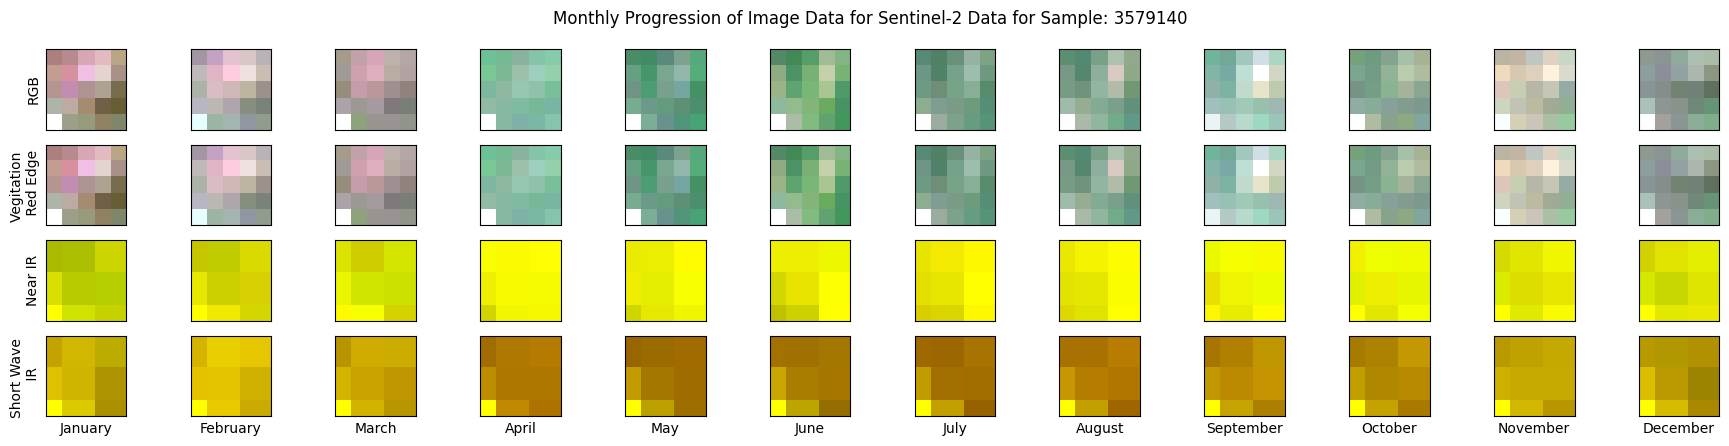

In [ ]:



indexToPlot = random.randint(0, df1Tar.shape[0])
sampleToPlot = 234244

sampleIndex = df1Tar[df1Tar['ID'] == sampleToPlot].index.tolist()



tensorTest = df1Tar.loc[indexToPlot, 'imgData']



figImg, axImg = plt.subplots(nrows = 4, ncols = 12, figsize = (12*1.5,3*1.5))

channels = ['RGB', 'Vegitation \n Red Edge', 'Near IR',  'Short Wave \n IR']
months = ["January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"]

def normaliseRGB(imageArr):
    for c in range(3):
        maxVal = imageArr[:, :, c].max()
        if maxVal > 0:
            imageArr[:, :, c] = imageArr[:, :, c]/maxVal
    return imageArr

for i in range(12*4):
    a = i // 12
    b = i % 12

    axImg[a, b].set_aspect(1)
    axImg[3, b].set_xlabel(months[b])
    axImg[a, 0].set_ylabel(channels[a])

    axImg[a, b].xaxis.set_major_locator(ticker.NullLocator())
    axImg[a, b].yaxis.set_major_locator(ticker.NullLocator())

for b in range(12):
    # RGB
    rgb = tensorTest[b, [2, 1, 0], :, :] 
    rgb_np = normaliseRGB(rgb.permute(1, 2, 0).numpy())

    # Vegitation Red Edge
    vre = tensorTest[b, [3, 4, 5], :, :] 
    vre_np = normaliseRGB(rgb.permute(1, 2, 0).numpy())

    # NIR - only two channels so use zeros for the third
    nir = tensorTest[b, 6]
    nirA = tensorTest[b, 7]
    nirInRGB = torch.stack([nir, nirA, torch.zeros_like(nirA)], dim =0)
    nirInRGB_np = normaliseRGB(nirInRGB.permute(1, 2, 0).numpy())

    # SWIR - only two channels so use zeros for the third
    swir1 = tensorTest[b, 8]
    swir2 = tensorTest[b, 9]
    swirInRGB = torch.stack([swir1, swir2, torch.zeros_like(swir1)], dim =0)
    swirInRGB_np = normaliseRGB(swirInRGB.permute(1, 2, 0).numpy())

    axImg[0, b].imshow(rgb_np)
    axImg[1, b].imshow(vre_np)
    axImg[2, b].imshow(nirInRGB_np)
    axImg[3, b].imshow(swirInRGB_np)
    
figImg.suptitle('Monthly Progression of Image Data for Sentinel-2 Data for Sample: '+ str( df1Tar.loc[indexToPlot, 'ID']))
figImg.tight_layout()


## Notes
- Data is missing for some months, inconsitently
- NIR and SWIR only have 2 channels so not a true RGB image
- 

# Making a Single DataFrame
- As before but with an extra column for the relevant tensor

In [11]:
def processTarJSONImg(path):
    '''Takes the path of 1 tar file and returns a dataframe with all data, ignoring missing values'''

    JSONTypes = ['.auxiliary', '.text']

    dfs = [] #list of 3 dataframes from each type of file in one tar file
    
    allMissingData = []
    for JSONType in JSONTypes:
        dfJSON, missingData = processTarJSON(path, JSONType)

        dfs.append(dfJSON)
        allMissingData.append[missingData]

    dfs.append(process_tarImg(path))

    #print(type(dfs[0]['ID'].iloc[0]))
    #print(type(dfs[1]['ID'].iloc[0]))
    #print(type(dfs[2]['ID'].iloc[0]))

    #drop data that has any missing JSON data
    for dfI in dfs:
        dfI = dfI[~dfI['ID'].isin(allMissingData)]

    #merge 3 dataframes by ID
    dfTemp = dfs[0].merge(dfs[1], on='ID')
    df = dfTemp.merge(dfs[2], on='ID')

    id_col = df.pop('ID')
    df.insert(0, 'ID', id_col)


    df[df.select_dtypes(np.float64).columns] = df.select_dtypes(np.float64).astype(np.float32)
    df[df.select_dtypes(np.int64).columns] = df.select_dtypes(np.int64).astype(np.float32)


    
    return df

def processTarJSON(path, jsonType):
    ''' takes the path of 1 tar files and JSON file type (auxiliary or text) and returns a dataframe of all json data'''
    missingDataIDs = []
    rows = []
    with tarfile.open(path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(jsonType+'.json'):
                f = tar.extractfile(member)
                if f:
                    obj = json.loads(f.read().decode("utf-8"))
                    if jsonType == '.text':
                        ID = member.name.split('\\')[-1].split('.')[0]
                        #print(pathAsList)
                        obj['ID'] = int(ID)
                    else:
                        try:
                            obj['ID'] = obj['sample_id']
                        except:
                            #print('Error Processing Sample')
                            #print(path)
                            #print(member.name)
                            missingDataIDs.append(int(member.name.split('\\')[-1].split('.')[0]))
                    rows.append(obj)

    df = pd.DataFrame(rows)

    
    #df.head()
    df['ID'] = pd.to_numeric(df['ID'], errors='coerce').astype(np.int32)
    return df, missingDataIDs
 

In [19]:
tarPath = 'GlobalGeoTree-6M\\GlobalGeoTree-6M\\GGT_3500001_3600000-000000.tar'

dfOneTar = processTarJSONImg(tarPath)

In [20]:
dfOneTar.dtypes

ID                         int32
sample_id                float32
longitude                float32
latitude                 float32
elevation                float32
slope                    float32
aspect                   float32
soil_moisture_0_5cm      float32
soil_moisture_5_15cm     float32
soil_moisture_15_30cm    float32
bio01                    float32
bio02                    float32
bio03                    float32
bio04                    float32
bio05                    float32
bio06                    float32
bio07                    float32
bio08                    float32
bio09                    float32
bio10                    float32
bio11                    float32
bio12                    float32
bio13                    float32
bio14                    float32
bio15                    float32
bio16                    float32
bio17                    float32
bio18                    float32
bio19                    float32
level0                    object
level1_fam

In [ ]:
dfOneTar.memory_usage(deep=True).sum() / 1024**2

np.float64(33.61356830596924)

## For all Tar Files

In [12]:
folder = Path("GlobalGeoTree-6M/GlobalGeoTree-6M/")

dfAllImg = pd.DataFrame()

tar_files = list(folder.glob("*.tar"))  # so tqdm knows the total

for idx, tar_file in tqdm(enumerate(tar_files), total=len(tar_files), desc="Processing tar files"):
    if idx >= 18:
        dfTemp = processTarJSONImg(tar_file)
        #dfAllImg = pd.concat([dfAllImg, dfTemp], ignore_index=True)
        torch.save(dfTemp, "GlobalGeoTree-6M/Chunks/Chunk-"+str(idx)+".pth")

Processing tar files:  15%|█▌        | 18/118 [00:04<00:23,  4.20it/s]


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

# To Load all Data

In [ ]:
chunk_folder = Path("GlobalGeoTree-6M/Chunks")

chunk_files = sorted(chunk_folder.glob("Chunk-*.pth"))

dfAllImg = pd.concat(
    [torch.load(chunk_file) for chunk_file in chunk_files],
    ignore_index=True
)